# CAMM Hackathon 12: Real-Time Drift Correction

In this challenge, the image is acquired line-by-line while the sample drifts. Your goal is to estimate that drift online and correct the image as the scan arrives.

## Task

Build a method that, for each newly acquired scan line:

- estimates the current drift
- updates the reconstructed image in real time
- produces a corrected final image

Keep the solution simple and fast enough to run during acquisition.

## What is provided

This notebook gives you:

- one STEM image to use as source data
- several synthetic drift models
- a simulator that corrupts the image line-by-line
- a streaming generator that mimics real-time acquisition

You only need to focus on the correction strategy.

## 1. Setup

In [1]:
# Install dependencies (Colab / fresh environment)
!pip -q install SciFiReaders gdown


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.0/150.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB

In [2]:
from pathlib import Path

file_id = "16Oavm1j0gcGR2mPXWCAqLfVm1MSngy1Z"
filename = "1547 STEM 1.45 Mx HAADF 0001.emd"

if not Path(filename).exists():
    !gdown {file_id} -O "{filename}"
else:
    print(f"Using existing file: {filename}")


Downloading...
From: https://drive.google.com/uc?id=16Oavm1j0gcGR2mPXWCAqLfVm1MSngy1Z
To: /content/1547 STEM 1.45 Mx HAADF 0001.emd
100% 8.85M/8.85M [00:00<00:00, 70.9MB/s]


## 2. Imports

In [3]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from SciFiReaders import EMDReader


## 3. Drift Models

These helper functions generate different drift trajectories. They are provided for testing and benchmarking.

In [4]:
#@title drift models




def drift_constant_velocity(
    n_lines: int,
    vx: float = 0.02,
    vy: float = 0.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Constant-velocity drift.

    Model:
        ux(t) = u0x + vx * t
        uy(t) = u0y + vy * t

    Parameters
    ----------
    n_lines : int
        Number of scan lines.
    vx, vy : float
        Drift velocity in pixels per unit time.
    dt : float
        Time step per line.
    u0x, u0y : float
        Initial drift offsets in pixels.

    Returns
    -------
    t : ndarray, shape (n_lines,)
        Time axis.
    ux, uy : ndarray, shape (n_lines,)
        Drift trajectory in pixels.
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + vx * t
    uy = u0y + vy * t
    return t, ux, uy


def drift_constant_velocity_random_walk(
    n_lines: int,
    vx0: float = 0.02,
    vy0: float = 0.0,
    sigma_ax: float = 0.002,
    sigma_ay: float = 0.002,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
    seed: int | None = None,
):
    """
    Constant-velocity model with random-walk velocity.

    State evolution:
        vx[t+1] = vx[t] + eps_x
        vy[t+1] = vy[t] + eps_y
        ux[t+1] = ux[t] + vx[t] * dt
        uy[t+1] = uy[t] + vy[t] * dt

    This is a very good default Kalman-style drift model.

    Parameters
    ----------
    n_lines : int
        Number of scan lines.
    vx0, vy0 : float
        Initial velocities in pixels per unit time.
    sigma_ax, sigma_ay : float
        Std of velocity perturbation per step.
    dt : float
        Time step per line.
    u0x, u0y : float
        Initial offsets.
    seed : int or None
        Random seed.

    Returns
    -------
    t, ux, uy : ndarray
        Time axis and drift trajectories.
    """
    rng = np.random.default_rng(seed)

    t = np.arange(n_lines, dtype=float) * dt
    ux = np.zeros(n_lines, dtype=float)
    uy = np.zeros(n_lines, dtype=float)
    vx = np.zeros(n_lines, dtype=float)
    vy = np.zeros(n_lines, dtype=float)

    ux[0], uy[0] = u0x, u0y
    vx[0], vy[0] = vx0, vy0

    for i in range(1, n_lines):
        vx[i] = vx[i - 1] + rng.normal(0.0, sigma_ax)
        vy[i] = vy[i - 1] + rng.normal(0.0, sigma_ay)

        ux[i] = ux[i - 1] + vx[i - 1] * dt
        uy[i] = uy[i - 1] + vy[i - 1] * dt

    return t, ux, uy


def drift_creep_log(
    n_lines: int,
    ax: float = 2.0,
    ay: float = 0.5,
    tau_x: float = 20.0,
    tau_y: float = 20.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Logarithmic creep-like drift.

    Model:
        ux(t) = u0x + ax * log(1 + t / tau_x)
        uy(t) = u0y + ay * log(1 + t / tau_y)

    Useful as a simple AFM-like creep surrogate.

    Parameters
    ----------
    ax, ay : float
        Drift amplitudes in pixels.
    tau_x, tau_y : float
        Characteristic time scales.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * np.log1p(t / tau_x)
    uy = u0y + ay * np.log1p(t / tau_y)
    return t, ux, uy


def drift_creep_exponential(
    n_lines: int,
    ax: float = 2.0,
    ay: float = 0.5,
    tau_x: float = 30.0,
    tau_y: float = 30.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Exponential relaxation / creep model.

    Model:
        ux(t) = u0x + ax * (1 - exp(-t / tau_x))
        uy(t) = u0y + ay * (1 - exp(-t / tau_y))

    Good when drift is strongest at the beginning and saturates.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * (1.0 - np.exp(-t / tau_x))
    uy = u0y + ay * (1.0 - np.exp(-t / tau_y))
    return t, ux, uy


def drift_oscillatory(
    n_lines: int,
    ax: float = 0.5,
    ay: float = 0.2,
    freq_x: float = 0.02,
    freq_y: float = 0.03,
    phase_x: float = 0.0,
    phase_y: float = 0.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Oscillatory drift model.

    Model:
        ux(t) = u0x + ax * sin(2*pi*freq_x*t + phase_x)
        uy(t) = u0y + ay * sin(2*pi*freq_y*t + phase_y)

    Useful as a toy vibration / periodic instability component.

    Parameters
    ----------
    ax, ay : float
        Oscillation amplitudes in pixels.
    freq_x, freq_y : float
        Frequencies in cycles per unit time.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * np.sin(2 * np.pi * freq_x * t + phase_x)
    uy = u0y + ay * np.sin(2 * np.pi * freq_y * t + phase_y)
    return t, ux, uy


def drift_composite(
    n_lines: int,
    dt: float = 1.0,
    linear_vx: float = 0.01,
    linear_vy: float = 0.0,
    creep_ax: float = 1.0,
    creep_ay: float = 0.3,
    creep_tau_x: float = 25.0,
    creep_tau_y: float = 25.0,
    osc_ax: float = 0.1,
    osc_ay: float = 0.05,
    osc_freq_x: float = 0.02,
    osc_freq_y: float = 0.015,
    phase_x: float = 0.0,
    phase_y: float = 0.0,
    noise_sigma_x: float = 0.02,
    noise_sigma_y: float = 0.02,
    u0x: float = 0.0,
    u0y: float = 0.0,
    seed: int | None = None,
):
    """
    Composite drift model:
    linear trend + creep + oscillation + small random noise.

    This is often the most realistic general-purpose simulator.

    Returns
    -------
    t, ux, uy : ndarray
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_lines, dtype=float) * dt

    linear_x = linear_vx * t
    linear_y = linear_vy * t

    creep_x = creep_ax * (1.0 - np.exp(-t / creep_tau_x))
    creep_y = creep_ay * (1.0 - np.exp(-t / creep_tau_y))

    osc_x = osc_ax * np.sin(2 * np.pi * osc_freq_x * t + phase_x)
    osc_y = osc_ay * np.sin(2 * np.pi * osc_freq_y * t + phase_y)

    noise_x = rng.normal(0.0, noise_sigma_x, size=n_lines)
    noise_y = rng.normal(0.0, noise_sigma_y, size=n_lines)

    ux = u0x + linear_x + creep_x + osc_x + noise_x
    uy = u0y + linear_y + creep_y + osc_y + noise_y

    return t, ux, uy

### Visualize example drift trajectories

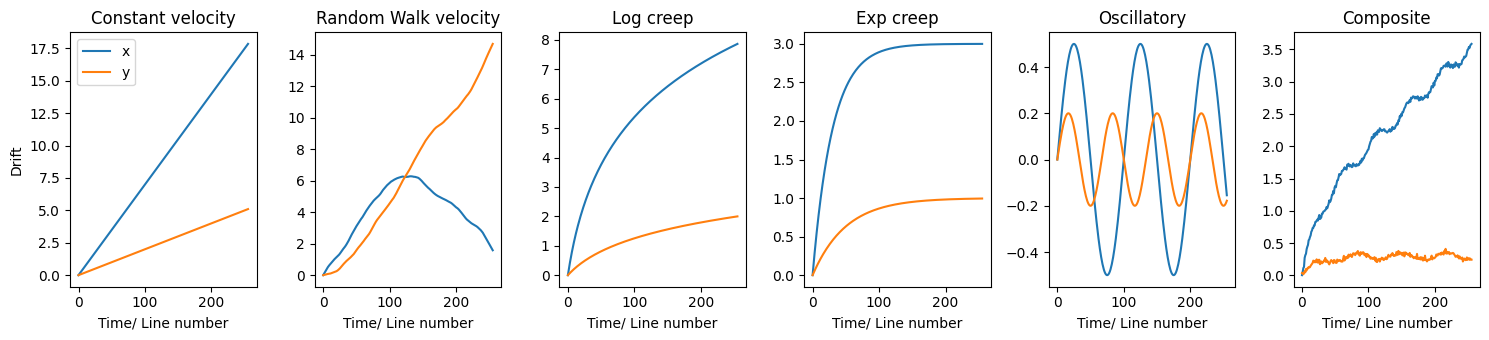

In [5]:
import matplotlib.pyplot as plt

n_lines = 256

fig, axes = plt.subplots(1, 6, figsize=(15, 3.5))

# --- 1. Constant velocity ---
t, ux1, uy1 = drift_constant_velocity(n_lines, vx=0.07, vy=0.02)
axes[0].plot(t, ux1, label='x')
axes[0].plot(t, uy1, label='y')
axes[0].legend()
axes[0].set_title("Constant velocity")

# --- 2. Random walk velocity ---
t, ux2, uy2 = drift_constant_velocity_random_walk(
    n_lines,
    vx0=0.07,
    vy0=0.01,
    sigma_ax=0.005,
    sigma_ay=0.005,
    seed=0
)
axes[1].plot(t, ux2, label='x')
axes[1].plot(t, uy2, label='y')
axes[1].set_title("Random Walk velocity")

# --- 3. Log creep ---
t, ux3, uy3 = drift_creep_log(n_lines, ax=3.0, ay=1.0, tau_x=20, tau_y=40)
axes[2].plot(t, ux3)
axes[2].plot(t, uy3)
axes[2].set_title("Log creep")

# --- 4. Exp creep ---
t, ux4, uy4 = drift_creep_exponential(n_lines, ax=3.0, ay=1.0, tau_x=30, tau_y=50)
axes[3].plot(t, ux4)
axes[3].plot(t, uy4)
axes[3].set_title("Exp creep")

# --- 5. Oscillatory ---
t, ux5, uy5 = drift_oscillatory(
    n_lines, ax=0.5, ay=0.2, freq_x=0.01, freq_y=0.015
)
axes[4].plot(t, ux5)
axes[4].plot(t, uy5)
axes[4].set_title("Oscillatory")

# --- 6. Composite ---
t, ux6, uy6 = drift_composite(n_lines, seed=2)
axes[5].plot(t, ux6)
axes[5].plot(t, uy6)
axes[5].set_title("Composite")

# --- formatting ---
for ax in axes:
    #ax.set_xticks([])   # cleaner
    #ax.set_yticks([])
    ax.set_xlabel("Time/ Line number")


#axes[0].set_xlabel("Time")
axes[0].set_ylabel("Drift")


fig.tight_layout()
plt.show()

## 4. Load the Source Image

In [6]:
emd_path = Path("1547 STEM 1.45 Mx HAADF 0001.emd")
reader = EMDReader(str(emd_path))
data = reader.read()

haadf_data = data["Channel_000"][:]
print("Loaded image shape:", haadf_data.shape)


Loaded image shape: (2048, 2048)


## 5. Drift Simulator

This helper creates a corrupted scan from a clean image and returns the ground-truth drift used to generate it.

In [7]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Any
from scipy.ndimage import map_coordinates


@dataclass
class DriftSimulationResult:
    cropped_reference: np.ndarray
    cropped_corrupted: np.ndarray
    t: np.ndarray
    ux: np.ndarray
    uy: np.ndarray
    model_name: str
    model_kwargs: dict[str, Any]
    crop_bbox: tuple[int, int, int, int]  # y0, y1, x0, x1


def simulate_scan_drift_cropped_output(
    image: np.ndarray,
    model: str | Callable[..., tuple[np.ndarray, np.ndarray, np.ndarray]],
    model_kwargs: dict | None = None,
    out_shape: tuple[int, int] | None = None,
    dt: float = 1.0,
    interpolation_order: int = 1,
    extra_margin: int = 2,
    drift_models: dict[str, Callable] | None = None,
):
    """
    Simulate line-by-line drift, but return only a central cropped output.
    Important: drifted sampling is performed from the FULL image, not from a pre-cropped image.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image.
    model : str or callable
        Drift model name or callable returning (t, ux, uy).
    model_kwargs : dict or None
        Parameters for drift model.
    out_shape : tuple[int, int] or None
        Output cropped shape (H, W). If None, use the maximal safe central crop.
    dt : float
        Time step per line.
    interpolation_order : int
        Interpolation order for map_coordinates.
    extra_margin : int
        Extra safety pixels beyond max drift.
    drift_models : dict or None
        Optional registry of named drift models.

    Returns
    -------
    DriftSimulationResult
    """
    if image.ndim != 2:
        raise ValueError("image must be a 2D array")

    H, W = image.shape
    model_kwargs = {} if model_kwargs is None else dict(model_kwargs)

    if drift_models is None:
        drift_models = {
            "constant_velocity": drift_constant_velocity,
            "random_walk_velocity": drift_constant_velocity_random_walk,
            "creep_log": drift_creep_log,
            "creep_exponential": drift_creep_exponential,
            "oscillatory": drift_oscillatory,
            "composite": drift_composite,
        }

    # resolve model
    if isinstance(model, str):
        if model not in drift_models:
            raise ValueError(f"Unknown model '{model}'. Available: {list(drift_models)}")
        model_fn = drift_models[model]
        model_name = model
    else:
        model_fn = model
        model_name = getattr(model, "__name__", "custom_model")

    # determine number of lines
    if out_shape is not None:
        out_h, out_w = out_shape
        model_kwargs["n_lines"] = out_h
    else:
        model_kwargs.setdefault("n_lines", H)

    model_kwargs.setdefault("dt", dt)

    # generate drift
    t, ux, uy = model_fn(**model_kwargs)
    ux = np.asarray(ux, dtype=float)
    uy = np.asarray(uy, dtype=float)

    if ux.shape != uy.shape:
        raise ValueError("ux and uy must have the same shape")

    n_lines = len(ux)

    # safe crop margins
    margin_x = int(np.ceil(np.max(np.abs(ux)))) + extra_margin
    margin_y = int(np.ceil(np.max(np.abs(uy)))) + extra_margin

    safe_h = H - 2 * margin_y
    safe_w = W - 2 * margin_x

    if safe_h <= 0 or safe_w <= 0:
        raise ValueError("Image too small for requested drift magnitude")

    if out_shape is None:
        out_h = min(n_lines, safe_h)
        out_w = safe_w
    else:
        out_h, out_w = out_shape
        if n_lines != out_h:
            raise ValueError(
                f"len(ux)={n_lines} must match out_shape[0]={out_h}"
            )
        if out_h > safe_h or out_w > safe_w:
            raise ValueError(
                f"Requested out_shape={out_shape} exceeds safe crop {(safe_h, safe_w)}"
            )

    # define central crop in the reference image
    y0 = (H - out_h) // 2
    x0 = (W - out_w) // 2
    y1 = y0 + out_h
    x1 = x0 + out_w

    cropped_reference = image[y0:y1, x0:x1]

    # simulate corrupted cropped output using FULL image coordinates
    cropped_corrupted = np.zeros((out_h, out_w), dtype=float)
    x_local = np.arange(out_w, dtype=float)

    for i in range(out_h):
        y_full = np.full(out_w, y0 + i + uy[i], dtype=float)
        x_full = x0 + x_local + ux[i]

        cropped_corrupted[i] = map_coordinates(
            image,
            [y_full, x_full],
            order=interpolation_order,
            mode="nearest",
        )

    return DriftSimulationResult(
        cropped_reference=cropped_reference,
        cropped_corrupted=cropped_corrupted,
        t=t[:out_h],
        ux=ux[:out_h],
        uy=uy[:out_h],
        model_name=model_name,
        model_kwargs=model_kwargs,
        crop_bbox=(y0, y1, x0, x1),
    )

## 6. Create a Sample Drifted Image

Use this synthetic example to develop and debug your method.

In [8]:
result = simulate_scan_drift_cropped_output(
    image=haadf_data,
    model="random_walk_velocity",
    model_kwargs={
        "vx0": 0.13,
        "vy0": 0.17,
        "sigma_ax": 0.03,
        "sigma_ay": 0.03,
        "seed": 1,
    },
    out_shape=(256, 256),
    interpolation_order=1,
    extra_margin=3,
)

img_ref = result.cropped_reference
img_cor = result.cropped_corrupted
ux = result.ux
uy = result.uy


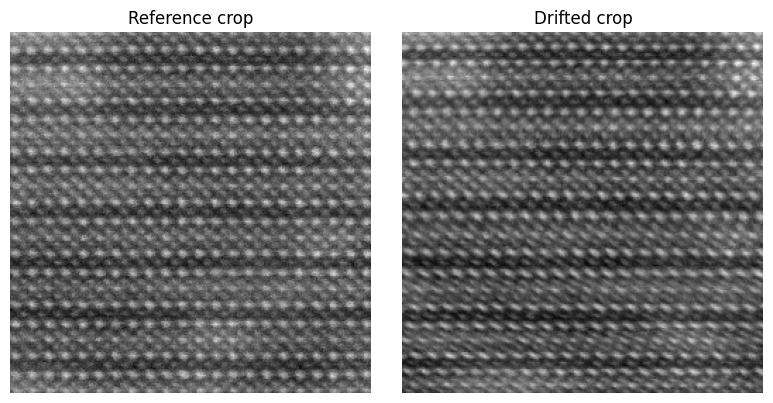

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_ref, cmap="gray")
axes[0].set_title("Reference crop")
axes[0].axis("off")

axes[1].imshow(img_cor, cmap="gray")
axes[1].set_title("Drifted crop")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 7. Streaming Interface

The function below yields the scan one line at a time, like a live acquisition stream.

In [10]:
from typing import Callable, Any, Iterator

def corrupted_image_scan_stream(
    corrupted_image: np.ndarray,
    true_ux: np.ndarray | None = None,
    true_uy: np.ndarray | None = None,
) -> Iterator[dict]:
    """
    Yield scan progress line-by-line.

    Returns a dict containing:
    - current line index
    - current line
    - partial image acquired so far
    - optional true drift
    """
    if corrupted_image.ndim != 2:
        raise ValueError("corrupted_image must be a 2D array")

    H, W = corrupted_image.shape
    partial = np.full((H, W), np.nan, dtype=float)

    for i in range(H):
        partial[i] = corrupted_image[i]

        item = {
            "line_index": i,
            "line": corrupted_image[i].copy(),
            "partial_image": partial.copy(),
        }

        if true_ux is not None:
            item["ux_true"] = float(true_ux[i])
        if true_uy is not None:
            item["uy_true"] = float(true_uy[i])

        yield item

## 8. Your Code

Suggested outputs:

- corrected image
- estimated drift versus line index
- short note on your approach and assumptions

In [ ]:
#your code

## 9. Optional Demo

This cell visualizes how the corrupted image is revealed during acquisition.

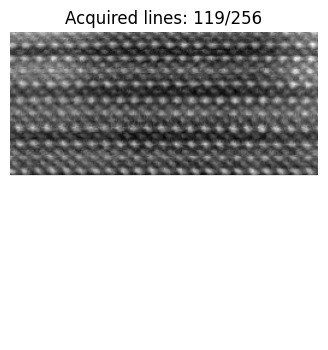

KeyboardInterrupt: 

In [11]:
stream = corrupted_image_scan_stream(img_cor)

for _ in range(len(img_cor)):
    frame = next(stream)
    clear_output(wait=True)
    plt.figure(figsize=(4, 4))
    plt.imshow(frame["partial_image"], cmap="gray")
    plt.title(f"Acquired lines: {frame['line_index'] + 1}/{len(img_cor)}")
    plt.axis("off")
    plt.show()
    time.sleep(0.05)
